# PyTorch 3D Deep Learning Development

## Import Library

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import numpy

In [2]:
import random
import torch

from dataclasses import dataclass

@dataclass
class SystemConfig:
    seed: int = 42  # seed number to set the state of all random number generators
    cudnn_benchmark_enabled: bool = False  # enable CuDNN benchmark for the sake of performance
    cudnn_deterministic: bool = True  # make cudnn deterministic (reproducible training)

class AverageMeter:
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, count=1):
        self.val = val
        self.sum += val * count
        self.count += count
        self.avg = self.sum / self.count

def setup_system(system_config: SystemConfig) -> None:
    torch.manual_seed(system_config.seed)
    np.random.seed(system_config.seed)
    random.seed(system_config.seed)
    torch.set_printoptions(precision=10)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(system_config.seed)
        torch.backends.cudnn_benchmark_enabled = system_config.cudnn_benchmark_enabled
        torch.backends.cudnn.deterministic = system_config.cudnn_deterministic

## 1. Load the Dataset

In [3]:
def check_data(window):

    # Check if the window shape matches the expected 6x13
    expected_shape = (6, 13)
    if window.shape != expected_shape:
        raise ValueError(f"Window shape is {window.shape}, but expected {expected_shape}.")
    
    channel_positions = {
        'S1_D1 hbo' : (0,4), 'S1_D3 hbo' : (2,2), 'S2_D2 hbo' : (0,8), 'S2_D1 hbo' : (1,6),    # Ch1 - Ch4
        'S2_D5 hbo' : (2,8), 'S3_D1 hbo' : (2,4), 'S3_D3 hbo' : (3,2), 'S3_D4 hbo' : (3,4),    # Ch5 - Ch8 
        'S3_D6 hbo' : (4,3), 'S4_D4 hbo' : (3,6), 'S4_D5 hbo' : (3,8), 'S4_D7 hbo' : (4,7),    # Ch9 - Ch12
        'S5_D2 hbo' : (2,10), 'S5_D5 hbo' : (3,10), 'S5_D8 hbo' : (4,12), 'S6_D3 hbo' : (4,0), # Ch13 - Ch16 
        'S6_D6 hbo' : (5,1), 'S7_D4 hbo' : (4,5), 'S7_D6 hbo' : (5,3), 'S7_D7 hbo' : (5,6),    # Ch17 - Ch20
        'S8_D5 hbo' : (4,9), 'S8_D7 hbo' : (5,9), 'S8_D8 hbo' : (5,11),                        # Ch21 - Ch23
    }

    # Dictionary to store the values of each channel position
    channel_values = {}

    # Check each channel position
    for channel, (row, col) in channel_positions.items():
        # Ensure the position is within the bounds of the window
        if row >= expected_shape[0] or col >= expected_shape[1]:
            raise ValueError(f"Channel position {row}, {col} for {channel} is out of bounds.")
        
        # Get the value from the window at the specified position
        value = window[row, col]
        
        # Check if the value at the position is non-zero
        if value == 0:
            raise ValueError(f"Value at position {row}, {col} for {channel} is zero.")
        
        # Store the value for the channel
        channel_values[channel] = value

    return channel_values

def process_first_sample(task_loaders):
    # Unpack the tuple of task_loader
    train_loader, val_loader = task_loaders

    for sample, label in train_loader:
        sequence = sample.squeeze(1)

        first_sequence = sequence[0]  

        window = first_sequence[0].numpy()

        print(window)

        # Apply check_data method to the first window
        try:
            channel_values = check_data(window)

            print("\n-----------------------------------")
            
            # Print the each channel from the loop
            for channel, value in channel_values.items():
                print(f"{channel}: {value}")
                
            return channel_values  # Return channel values after processing the first sample
        except ValueError as e:
            print(f"Error: {e}")
            return None
        
        # We only process one sample, so break after the first iteration
        break

def check_batch_statistics(task_loaders):
    # Unpack the tuple of task_loaders
    train_loader, _ = task_loaders

    # Get one batch of data
    samples, labels, subjects = next(iter(train_loader))  # Samples shape: (batch_size, 3, seq_len, height, width)
    
    # Print the shape of the raw batch data
    print("\n-----------------------------------")
    print(f"Batch sample shape: {samples.shape}")  # Shape: (batch_size, 3, seq_len, height, width)

    # Calculate mean and std across batch, sequence length, height, and width, separately for each channel
    batch_mean = samples.mean(dim=[0, 2, 3, 4])  # Mean across batch, sequence, height, width (keep channels)
    batch_std = samples.std(dim=[0, 2, 3, 4])    # Std across batch, sequence, height, width (keep channels)

    # Print the calculated statistics per channel
    print("\n-----------------------------------")
    for c, (mean, std) in enumerate(zip(batch_mean, batch_std)):
        print(f"Channel {c + 1}: Mean = {mean.item():.6f}, Std = {std.item():.6f}")
        
def check_distribution(dataset, task_name="Dataset"):
    print(f"\nTotal samples in {task_name} dataset: {len(dataset)}")
    
    # Display shape of one data sample
    sample_data, sample_label = dataset[0]
    print(f"Shape of one {task_name} data sample: {sample_data.shape}")
    
    # Calculate and display class distribution
    unique_labels, counts = np.unique(dataset.labels, return_counts=True)
    label_counts = dict(zip(unique_labels, counts))
    print(f"{task_name} class distribution: {label_counts}")

### `Dataset` 

What is the difference between `fNIRSSequenceDatasetV1` and `fNIRSSequenceDatasetV2`? The difference is that `V1` uses windowed data as the samples for training/validation, while `V2` uses each epoch instead of windowed data as the samples for training/validation.

In [22]:
from torch.utils.data import Dataset
from einops import rearrange, repeat
import torch
from torch import nn
from torchvision.transforms.v2 import Compose, UniformTemporalSubsample, Normalize, Lambda, Resize
from torchvision.transforms.functional import InterpolationMode

class fNIRSSequenceDatasetV1(Dataset):
    def __init__(self, root_dir, window_duration, transform=None, data_type='hbo', task_type='GNG', max_trials=None):
        """
        Initialize the dataset.

        Parameters:
        - root_dir: the root directory containing healthy/anxiety data.
        - window_duration: the duration of each window in seconds.
        - transform: optional transform to apply to the sequences.
        - data_type: either 'hbo', 'hbr', 'hbt', 'hbo+hbr', 'hbo+hbt', 'hbr+hbt', or 'all' to load HbO, HbR, HbT, or combinations.
        - task_type: the task type to load (e.g., GNG, VF).
        - max_trials: maximum number of trials to load per subject (None for all trials).
        """
        self.root_dir = root_dir
        self.window_duration = window_duration
        self.transform = transform
        self.data_type = data_type.lower()
        self.data = []
        self.labels = []
        self.subjects = []  # Track subjects
        self.task_type = task_type
        self.max_trials = max_trials
        self.total_npy_files = 0  # Track total .npy files
        self.class_npy_count = {'healthy': 0, 'anxiety': 0}  # Count of .npy files per class
        self.class_subject_count = {'healthy': set(), 'anxiety': set()}  # Unique subjects per class
        self.subject_trial_count = {}  # Dictionary to track trials per subject

        # Define required types based on `data_type`
        self.required_types = self.data_type.split('+') if self.data_type != "all" else ['hbo', 'hbr', 'hbt']
        label_map = {'healthy': 0, 'anxiety': 1}

        # Traverse Healthy and Anxiety folders
        for label_name, label in label_map.items():
            label_path = os.path.join(self.root_dir, label_name)
            
            for subject in os.listdir(label_path):
                subject_path = os.path.join(label_path, subject, self.task_type)
                self.class_subject_count[label_name].add(subject)  # Add subject to the respective class set

                # Initialize trial count for this subject
                self.subject_trial_count[subject] = 0

                # Process each concentration type
                for data_type in self.required_types:
                    data_dir = os.path.join(subject_path, data_type.upper())
                    self.append_subject(data_dir, label, subject, label_name)

    def append_subject(self, data_dir, label, subject, label_name):
        """Load data for each subject."""
        if not os.path.exists(data_dir):
            return

        trial_count = 0
        # Check subfolders for trials (0, 1, 2, 3)
        for trial in sorted(os.listdir(data_dir)):
            if self.max_trials is not None and trial_count >= self.max_trials:
                break

            trial_dir = os.path.join(data_dir, trial)
            if os.path.isdir(trial_dir):
                for window_file in sorted(os.listdir(trial_dir), key=lambda x: int(x.split('.')[0])):
                    file_path = os.path.join(trial_dir, window_file)
                    if os.path.exists(file_path):
                        window = np.load(file_path)  # Shape: (time frames, height, width)
                        self.data.append(window)
                        self.labels.append(label)
                        self.subjects.append(subject)
                        self.total_npy_files += 1  # Increment total file count
                        self.class_npy_count[label_name] += 1  # Increment per-class file count

                # Increment trial count for this subject
                trial_count += 1
                self.subject_trial_count[subject] += 1

    def load_trial(self, trial_dir):
        """Load trial data as a single 3D tensor (time frames x height x width)."""
        windows = []
        for window_file in sorted(os.listdir(trial_dir), key=lambda x: int(x.split('.')[0])):
            file_path = os.path.join(trial_dir, window_file)
            if os.path.exists(file_path):
                window = np.load(file_path)  # Shape: (time frames, height, width)
                windows.append(window)
        return np.stack(windows) if windows else None

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        # Data shape: (time frames, height, width)
        sequence = torch.tensor(self.data[idx], dtype=torch.float32)  # Shape: (T, H, W)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        subject = self.subjects[idx]  # Include subject identifier

        # Add a channels dimension (1 for single-channel input) using einops
        sequence = rearrange(sequence, 't h w -> 1 t h w')  # Shape becomes (1, T, H, W)

        # Apply transformations if provided
        if self.transform:
            sequence = self.transform(sequence)
        
        return sequence, label, subject  

class fNIRSSequenceDatasetV2(Dataset):
    def __init__(self, root_dir, transform=None, data_type='hbo', task_type='GNG', max_trials=None):
        self.root_dir = root_dir
        self.transform = transform
        self.data_type = data_type.lower()
        self.data = []
        self.labels = []
        self.subjects = []
        self.task_type = task_type
        self.max_trials = max_trials
        self.class_subject_count = {'healthy': set(), 'anxiety': set()}
        self.subject_trial_count = {}  
        self.total_npy_files = 0

        self.required_types = self.data_type.split('+') if self.data_type != "all" else ['hbo', 'hbr', 'hbt']
        label_map = {'healthy': 0, 'anxiety': 1}

        for label_name, label in label_map.items():
            label_path = os.path.join(self.root_dir, label_name)
            for subject in os.listdir(label_path):
                subject_path = os.path.join(label_path, subject, self.task_type)
                self.class_subject_count[label_name].add(subject)

                # Initialize subject trial count
                self.subject_trial_count[subject] = 0

                for data_type in self.required_types:
                    data_dir = os.path.join(subject_path, data_type.upper())
                    if os.path.exists(data_dir):
                        self.append_trials(data_dir, label, subject, label_name)

    def append_trials(self, data_dir, label, subject, label_name):
        trial_count = 0
        for trial_file in sorted(os.listdir(data_dir), key=lambda x: int(x.split('.')[0])):
            if self.max_trials is not None and trial_count >= self.max_trials:
                break

            file_path = os.path.join(data_dir, trial_file)
            if os.path.exists(file_path):
                trial_data = np.load(file_path)
                self.data.append(trial_data)  # Store full trial for later transformation
                self.labels.append(label)
                self.subjects.append(subject)
                self.total_npy_files += 1
                trial_count += 1

                # Update the trial count for this subject
                self.subject_trial_count[subject] += 1

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sequence = self.data[idx]  # Shape: (T, H, W)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        subject = self.subjects[idx]

        # Add a channels dimension for compatibility with transformations
        sequence = torch.tensor(sequence, dtype=torch.float32)  # (T, H, W)
        sequence = rearrange(sequence, 't h w -> 1 t h w')  # Add channel dimension (1, T, H, W)

        # Apply transformations, including RGB conversion
        if self.transform:
            sequence = self.transform(sequence)

        return sequence, label, subject

class R2Plus1DTransform:
    def __init__(self, mean=None, std=None, normalize=False):
        """
        Initialize the transformation pipeline.

        Parameters:
        - mean: List of means for normalization (channels).
        - std: List of standard deviations for normalization (channels).
        - normalize: Whether to apply normalization (True) or not (False).
        """
        self.mean = mean if mean else [0.43216, 0.394666, 0.37645]
        self.std = std if std else [0.22803, 0.22145, 0.216989]
        self.normalize = Normalize(mean=self.mean, std=self.std)
        self.apply_normalize = normalize

    def __call__(self, tensor):
        """
        Apply the transformation.

        Parameters:
        - tensor: Input tensor of shape (1, T, H, W).

        Returns:
        - Transformed tensor of shape (3, T, H, W).
        """
        # Check the input shape
        if tensor.shape[0] != 1:
            raise ValueError(f"Expected tensor with a single channel, got shape {tensor.shape}.")

        # Expand from single channel (1) to three channels (3)
        tensor = repeat(tensor, "1 t h w -> c t h w", c=3)  # Shape: (3, T, H, W)

        # Apply normalization if enabled
        if self.apply_normalize:
            for c in range(3):
                tensor[c] = (tensor[c] - self.mean[c]) / self.std[c]

        return tensor
    
class ConvertToRGB(nn.Module):
    def forward(self, sequence):
        """
        Convert single-channel sequence data to RGB-like format.

        Parameters:
        - sequence (torch.Tensor): Input tensor of shape (1, T, H, W).

        Returns:
        - torch.Tensor: Transformed tensor of shape (3, T, H, W).
        """
        if sequence.shape[0] != 1:
            raise ValueError(f"Input tensor must have a single channel, but got shape {sequence.shape}")
        
        # Repeat the single channel across 3 channels to simulate RGB
        return sequence.repeat(3, 1, 1, 1)  # Shape becomes (3, T, H, W)
    
class RearrangeToTCHW(nn.Module):
    """
    Rearrange tensor to [..., T, C, H, W] for compatibility with UniformTemporalSubsample.
    """
    def forward(self, x):
        # Input: (C, T, H, W) -> Output: (T, C, H, W)
        return rearrange(x, 'c t h w -> t c h w')

class RearrangeBackToCTHW(nn.Module):
    """
    Rearrange tensor back to (C, T, H, W) after subsampling.
    """
    def forward(self, x):
        # Input: (T, C, H, W) -> Output: (C, T, H, W)
        return rearrange(x, 't c h w -> c t h w')

class AddGaussianNoise(nn.Module):
    """
    Custom transformation to add Gaussian noise to a tensor.
    """
    def __init__(self, mean=0.0, std=1.0):
        super().__init__()
        self.mean = mean
        self.std = std

    def forward(self, x):
        """
        Add Gaussian noise to the input tensor.

        Parameters:
        - x: Input tensor of any shape.

        Returns:
        - Tensor with Gaussian noise added.
        """
        return x + torch.randn_like(x) * self.std + self.mean

#### Create `Dataset` Object

In [26]:
transform = None

# Data directory corresponding to the task and window configuration
SHAPE = 'Shape (5, 7)'
DATA_DIR = fr'./data/{SHAPE}'

# Define the transformation pipeline
transform = Compose([
    RearrangeToTCHW(),                          # Rearrange to (T, C, H, W)
    UniformTemporalSubsample(num_samples=32),  
    Resize((112, 112), interpolation=InterpolationMode.BILINEAR, antialias=True),  
    RearrangeBackToCTHW(),                      # Rearrange back to (C, T, H, W)
    ConvertToRGB(),                             
    AddGaussianNoise(mean=0.0, std=0.05),       
])
dataset = fNIRSSequenceDatasetV2(root_dir=DATA_DIR, data_type='hbt', task_type='GNG', max_trials=1, transform=transform)

#### Visualize the `Dataset` Object

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4308221..0.9983765].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9696324..0.34261164].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.328905..-0.02170989].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.6037798..-0.007331893].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4651535..0.0356505].


Sample shape after RGB transform: torch.Size([3, 32, 112, 112])
Label: 0, Subject: AH050
Mean: -0.0070, Standard Deviation: 0.8212
Sample Minimum Value: -2.6037797927856445
Sample Maximum Value: 2.055692195892334


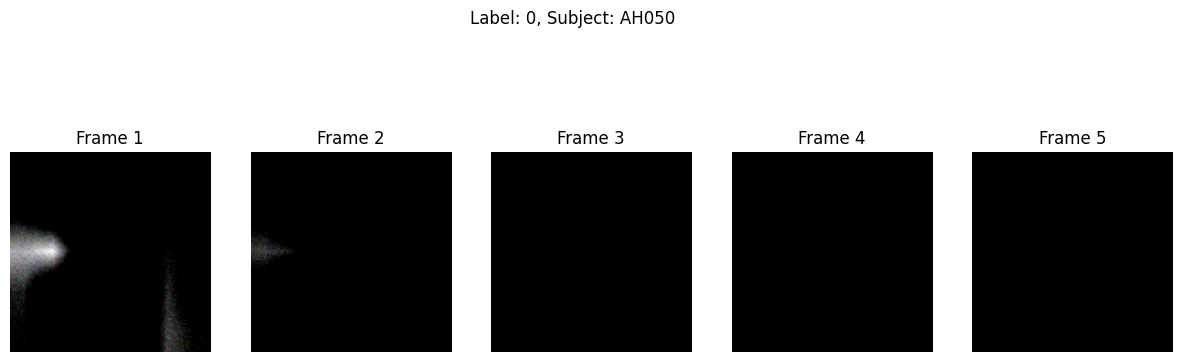

In [27]:
from einops import rearrange
import matplotlib.pyplot as plt

# Inspect the first sample in the dataset
sample, label, subject = dataset[0]

# Compute mean and std across all channels, time, and spatial dimensions
mean = sample.mean().item()
std = sample.std().item()

print(f"Sample shape after RGB transform: {sample.shape}")  # Should be (3, T, H, W)
print(f"Label: {label}, Subject: {subject}")
print(f"Mean: {mean:.4f}, Standard Deviation: {std:.4f}")

# Check the range of values in the tensor
print(f"Sample Minimum Value: {sample.min().item()}")
print(f"Sample Maximum Value: {sample.max().item()}")

# Rearrange to extract individual frames for visualization | Shape: (3, T, H, W) -> (T, 3, H, W)
frames = rearrange(sample, 'c t h w -> t c h w')  # Now each frame is (3, H, W)

# Visualize a few frames
num_frames_to_plot = 5  # Adjust as needed
fig, axes = plt.subplots(1, num_frames_to_plot, figsize=(15, 5))

for i, ax in enumerate(axes):
    if i >= frames.shape[0]:
        break
    frame = rearrange(frames[i], 'c h w -> h w c')  # (3, H, W) -> (H, W, C)
    ax.imshow(frame.cpu().numpy())  # Ensure the tensor is moved to CPU before conversion
    ax.set_title(f"Frame {i+1}")
    ax.axis('off')

plt.suptitle(f"Label: {label}, Subject: {subject}")
plt.show()


### Data Loader

- Step 1: Define the `fNIRSSequenceDataset`
- Step 2: Define Transformations Pipeline
- Step 3: Split `fnirsSequenceDataset` into Training, Validation, and Testing
- Step 4: Create a `DataLoader`

In [28]:
from sklearn.model_selection import StratifiedKFold, train_test_split
from imblearn.over_sampling import SMOTE
from torch.utils.data import DataLoader, Subset
import numpy as np
from collections import defaultdict

def get_loso_subject_loaders(dataset, batch_size, num_workers, use_smote=False):
    """
    Creates loaders for Leave-One-Subject-Out Cross Validation.
    Ensures each fold uses one subject as the validation set and the rest for training.
    """
    # Collect all subjects and their associated indices
    subject_to_indices = defaultdict(list)
    subject_labels = {}

    for idx, (data, label, subject) in enumerate(dataset):
        subject_to_indices[subject].append(idx)
        subject_labels[subject] = label

    # Get unique subjects
    subjects = list(subject_to_indices.keys())
    fold_data = []

    # Leave-One-Subject-Out CV
    for i, val_subject in enumerate(subjects):
        print(f"\nPreparing fold {i + 1}/{len(subjects)} with validation subject: {val_subject}")

        # Validation indices for the current subject
        val_indices = subject_to_indices[val_subject]
        
        # Training indices from all other subjects
        train_indices = [idx for subj in subjects if subj != val_subject for idx in subject_to_indices[subj]]
        
        # Logging the distribution of subjects in training and validation sets
        train_subjects = [subj for subj in subjects if subj != val_subject]
        val_subjects = [val_subject]

        # Debug information for each fold
        print(f"  Training subjects ({len(train_subjects)}): {train_subjects}")
        print(f"  Validation subject: {val_subjects}")
        print(f"  Number of training sequences: {len(train_indices)}")
        print(f"  Number of validation sequences: {len(val_indices)}")

        # Apply SMOTE if enabled
        if use_smote:
            train_data = [dataset.data[i] for i in train_indices]
            train_labels = [dataset.labels[i] for i in train_indices]
            
            # Apply SMOTE for class balancing in training set
            smote = SMOTE(random_state=42)
            train_data_smote, train_labels_smote = smote.fit_resample(
                np.array(train_data).reshape(len(train_data), -1),  # Flatten data for SMOTE
                train_labels
            )
            
            # Reshape data back to original shape after SMOTE
            train_data_smote = train_data_smote.reshape(-1, dataset.sequence_length, *train_data[0].shape[1:])
            
            # Create new dataset with SMOTE-balanced data
            train_dataset = fNIRSSequenceDataset(root_dir=dataset.root_dir, sequence_length=dataset.sequence_length)
            train_dataset.data = list(train_data_smote)
            train_dataset.labels = list(train_labels_smote)
            train_dataset.subjects = ['Synthetic'] * (len(train_data_smote) - len(train_subjects)) + train_subjects
            
            # Debugging information after SMOTE
            print(f"  Number of training sequences after SMOTE: {len(train_dataset.data)}")
        else:
            # Use original training data without SMOTE
            train_dataset = Subset(dataset, train_indices)

        # Create DataLoaders for each fold
        train_loader = DataLoader(
            train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers
        )
        val_loader = DataLoader(
            Subset(dataset, val_indices), batch_size=batch_size, shuffle=False, num_workers=num_workers
        )

        fold_data.append((train_loader, val_loader, val_subject))
    
    return fold_data

def get_stratified_kfold_subject_loaders(dataset, k_folds, batch_size, num_workers, train_transform=None, val_transform=None):
    """
    Creates stratified k-fold loaders with subject-level aggregation for single-task data.
    Ensures each subject's sequences are entirely in either the training or validation set.

    Parameters:
    - dataset: The original dataset containing subject-level data.
    - k_folds: Number of stratified folds.
    - batch_size: Batch size for DataLoaders.
    - num_workers: Number of workers for DataLoaders.
    - train_transform: Transformation pipeline for training data.
    - val_transform: Transformation pipeline for validation data.

    Returns:
    - fold_data: List of (train_loader, val_loader) tuples for each fold.
    """
    # Collect all subjects and their associated labels
    subject_to_indices = defaultdict(list)
    subject_labels = {}

    # Build mappings of subjects to data indices and labels
    for idx, (data, label, subject) in enumerate(dataset):
        subject_to_indices[subject].append(idx)
        subject_labels[subject] = label.item()

    # Get unique subjects and their labels for stratification
    subjects = list(subject_to_indices.keys())
    labels = [subject_labels[subject] for subject in subjects]
    
    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
    fold_data = []

    # Stratified k-fold split by subjects
    for fold_idx, (train_subject_indices, val_subject_indices) in enumerate(skf.split(subjects, labels)):
        print(f"\nPreparing fold {fold_idx + 1}/{k_folds}")

        # Map subject indices to data indices
        train_indices = [idx for subj_idx in train_subject_indices for idx in subject_to_indices[subjects[subj_idx]]]
        val_indices = [idx for subj_idx in val_subject_indices for idx in subject_to_indices[subjects[subj_idx]]]
        
        # Logging the distribution of subjects
        train_subjects = [subjects[subj_idx] for subj_idx in train_subject_indices]
        val_subjects = [subjects[subj_idx] for subj_idx in val_subject_indices]
        
        # Debugging subject-to-trial mapping
        train_trials = {subj: len(subject_to_indices[subj]) for subj in train_subjects}
        val_trials = {subj: len(subject_to_indices[subj]) for subj in val_subjects}

        print(f"  Train trials per subject: {train_trials}")
        print(f"  Validation trials per subject: {val_trials}")

        # Class distribution
        train_labels = [dataset.labels[i] for i in train_indices]
        val_labels = [dataset.labels[i] for i in val_indices]
        print(f"  Train class distribution: {dict(zip(*np.unique(train_labels, return_counts=True)))}")
        print(f"  Validation class distribution: {dict(zip(*np.unique(val_labels, return_counts=True)))}")

        # Create training and validation subsets
        train_dataset = Subset(dataset, train_indices)
        val_dataset = Subset(dataset, val_indices)

        # Assign transforms dynamically
        train_dataset.dataset.transform = train_transform
        val_dataset.dataset.transform = val_transform

        # Create DataLoaders for each fold
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

        fold_data.append((train_loader, val_loader))
    
    return fold_data

def get_holdout_subject_loaders(dataset, test_size, batch_size, num_workers, train_transform=None, val_transform=None):
    # Split subjects into training and validation sets
    subjects = np.array(dataset.subjects)
    unique_subjects = np.unique(subjects)
    train_subjects, val_subjects = train_test_split(
        unique_subjects, test_size=test_size, random_state=42
    )

    train_indices = [i for i, subj in enumerate(subjects) if subj in train_subjects]
    val_indices = [i for i, subj in enumerate(subjects) if subj in val_subjects]

    print("\nHoldout Subject Validation")
    print(f"  Number of training subjects: {len(train_subjects)}")
    print(f"  Number of validation subjects: {len(val_subjects)}")
    print(f"  Number of training sequences: {len(train_indices)}")
    print(f"  Number of validation sequences: {len(val_indices)}")

    train_dataset = Subset(dataset, train_indices)
    val_dataset = Subset(dataset, val_indices)

    # Assign separate transforms dynamically
    train_dataset.dataset.transform = train_transform
    val_dataset.dataset.transform = val_transform

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    return train_loader, val_loader

# def create_single_task_dataset(root_dir, task_name, task_config, data_type, max_trials=None, transform=None):
#     window_duration = task_config.get('window_duration', 0.8)  # Default to 0.8 seconds if not specified
#     print(f"Creating single-task dataset for '{task_name}' with window duration {window_duration}s and max_trials={max_trials}.")
#     dataset = fNIRSSequenceDatasetV1(
#         root_dir=root_dir,
#         window_duration=window_duration,
#         data_type=data_type,
#         task_type=task_name,
#         max_trials=max_trials,  
#         transform=transform
#     )
#     return dataset

def create_single_task_dataset(root_dir, task_name, data_type, max_trials=None):
    dataset = fNIRSSequenceDatasetV2(
        root_dir=root_dir,
        data_type=data_type,
        task_type=task_name,
        max_trials=max_trials,
        transform=None  # Transform will be assigned dynamically in loaders
    )
    return dataset

def get_data(root_dir, data_type='hbo', task_types=None, batch_size=8, test_size=0.2, 
             num_workers=0, use_stratified_kfold=False, k_folds=5, smote=False, 
             use_loso_cv=False, max_trials=None, train_transform=None, val_transform=None):
    if task_types is None:
        task_types = {'GNG': {'window_duration': 0.8}}

    task_name, task_config = next(iter(task_types.items()))
    dataset = create_single_task_dataset(root_dir, task_name, data_type, max_trials)

    print(f"Using single-task dataset for task '{task_name}' with task-specific configuration.")
    print(f"Total samples in dataset: {len(dataset)}")
    print(f"Trials per subject: {dataset.subject_trial_count}")

    sample_data, sample_label, sample_subject = dataset[0]
    print(f"{task_name} data shape: {sample_data.shape}, label: {sample_label}, subject: {sample_subject}")

    # Choose DataLoader creation method
    if use_loso_cv:
        return get_loso_subject_loaders(dataset, batch_size, num_workers, smote)
    elif use_stratified_kfold:
        return get_stratified_kfold_subject_loaders(dataset, k_folds, batch_size, num_workers, train_transform, val_transform)
    else:
        return get_holdout_subject_loaders(dataset, test_size, batch_size, num_workers, train_transform, val_transform)

`dim=[0, 2, 3, 4]` excludes the channel dimension, so the mean and standard deviation are calculated across all frames, height, and width but averaged over the batch dimension.

In [29]:
# Define default parameters
WINDOW_DURATION = 1

# Task configuration with dynamic window duration
task_types = {
    'GNG': {'window_duration': WINDOW_DURATION},  # Dynamic window duration for GNG task
}

# Training transformations
train_transform = Compose([
    RearrangeToTCHW(),                          # Rearrange to (T, C, H, W)
    UniformTemporalSubsample(num_samples=32),   # Subsample 32 frames
    Resize((112, 112), interpolation=InterpolationMode.BILINEAR, antialias=True),  # Resize spatial dimensions
    RearrangeBackToCTHW(),                      # Rearrange back to (C, T, H, W)
    ConvertToRGB(),                             # Convert single-channel to 3 channels
    AddGaussianNoise(mean=0.0, std=0.05),       # Add Gaussian noise
])

# Validation transformations
val_transform = Compose([
    RearrangeToTCHW(),                          # Rearrange to (T, C, H, W)
    UniformTemporalSubsample(num_samples=32),   # Subsample 32 frames
    Resize((112, 112), interpolation=InterpolationMode.BILINEAR, antialias=True),  # Resize spatial dimensions
    RearrangeBackToCTHW(),                      # Rearrange back to (C, T, H, W)
    ConvertToRGB(),                             # Convert single-channel to 3 channels
])

# Data directory corresponding to the task and window configuration
SHAPE = 'Shape (5, 7)'
DATA_DIR = fr'./data/{SHAPE}'

# Define parameters and initialize DataLoader
task_loaders = get_data(
    root_dir=DATA_DIR,
    data_type='hbt',  # Specify the data type (e.g., HbO + HbR)
    task_types=task_types,  # Pass the task configuration with window duration
    batch_size=8,  # Batch size for DataLoader
    test_size=0.2,  # Test size for holdout validation
    use_stratified_kfold=True,  # Use stratified k-fold cross-validation
    k_folds=5,  # Number of folds for stratified k-fold
    smote=False,  # Whether to use SMOTE for class balancing
    use_loso_cv=False,  # Whether to use Leave-One-Subject-Out (LOSO) cross-validation,
    max_trials=1,  # Maximum number of trials to load per subject,
    train_transform=train_transform,  # Training transformations
    val_transform=val_transform       # Validation transformations
)

Using single-task dataset for task 'GNG' with task-specific configuration.
Total samples in dataset: 53
Trials per subject: {'AH050': 1, 'AH049': 1, 'AH048': 1, 'AH047': 1, 'AH046': 1, 'AH045': 1, 'AH044': 1, 'AH043': 1, 'AH040': 1, 'AH039': 1, 'AH038': 1, 'AH037': 1, 'AH036': 1, 'AH035': 1, 'AH034': 1, 'AH033': 1, 'AH031': 1, 'AH030': 1, 'AH029': 1, 'AH028': 1, 'AH027': 1, 'AH026': 1, 'AH025': 1, 'AH024': 1, 'AH023': 1, 'AH022': 1, 'AH021': 1, 'AH020': 1, 'AH019': 1, 'AH018': 1, 'AH017': 1, 'AH015': 1, 'AH014': 1, 'LA063': 1, 'LA059': 1, 'LA058': 1, 'LA057': 1, 'LA054': 1, 'LA053': 1, 'LA052': 1, 'LA051': 1, 'LA042': 1, 'EA062': 1, 'EA061': 1, 'EA060': 1, 'EA055': 1, 'EA016': 1, 'EA012': 1, 'AA064': 1, 'AA056': 1, 'AA041': 1, 'AA013': 1, 'AA011': 1}
GNG data shape: torch.Size([1, 326, 5, 7]), label: 0, subject: AH050

Preparing fold 1/5
  Train trials per subject: {'AH050': 1, 'AH049': 1, 'AH048': 1, 'AH047': 1, 'AH046': 1, 'AH045': 1, 'AH044': 1, 'AH043': 1, 'AH040': 1, 'AH037': 1, '

## 2. Model Architecture

### C3D Model

- `Conv3D Layer`
  - $$Param=(Kernel Depth×Kernel Height×Kernel Width×In Channels×Out Channels)+Out Channels$$
  - Example Calculation: `Conv3d: 3-1 [1, 64, 128, 64, 64]` with **4,096 parameters**
    - Kernel size: 7 x 3 x 3
    - In Channels: 1
    - Out Channels: 64
    - Calculation
      - Param = (7 x 3 x 3 x 1 x 64) + 64 = 4096
- `BatchNorm3D Layer`
  - For a BatchNorm3D layer, the number of parameters is based on the number of output channels, as each channel has a learnable scaling (gamma) and shifting (beta) parameter.
  - $$Param=2×Out Channels$$
  - Example Calculation: `BatchNorm3d: 3-2 [1, 64, 128, 64, 64]` with **128 parameters**
    - Out Channels: 64
    - Calculation
      - Param = (2 x 64) = 128
- `Linear Layer`
  - $$Param=(In Features×Out Features)+Out Features$$
  - The addition of `Out Features` is for the bias term, which is again typically included.
  - Example Calculation: `Linear: 1-2 [1, 2048]` with **8,390,656 parameters**
    - In Features: Determined by the flattening of the previous convolutional block output.
    - Out Features: 2048
    - Suppose we flatten the output to 4096 features before this layer.
    - Calculation
      - Param = (4096×2048)+2048 = 8,388,608 + 2048 = 8,390,656 
- If you want to **preserve the spatial dimensions** (depth, height, width) after a convolution with any kernel size, the padding should be:
  $$Padding = (\frac{\text{Kernel Size} - 1}{2})$$

  - For any **odd-sized kernel** (like `7`, `3`, `5`) using $Padding = (\frac{\text{Kernel Size} - 1}{2})$ will preserve the spatial dimensions after convolution.
  - Input and Output Channels: The input and output channels do not affect the spatial dimensions, so the same padding will work regardless of the number of channels.
  - Example Calculation:
    - Depth (D): `(7-1)/2 = 3`
    - Height (H): `(3-1)/2 = 1`
    - Width (W): `(3-1)/2 = 1`

In [30]:
import torch
import torch.nn as nn
import torch.nn.init as init
from torchinfo import summary

class C3DModel(nn.Module):
    def __init__(self, num_classes=2, fusion=False, activation='relu'):
        super(C3DModel, self).__init__()

        self.fusion = fusion
        self.activation = activation.lower()  # Store the activation choice
        
        # Define the body (3D Conv blocks)
        self._body = nn.Sequential(
            self._conv3d_block(in_channels=1, out_channels=64, kernel_size=(3, 3, 3), padding=(1,1,1)),
            self._conv3d_block(in_channels=64, out_channels=128, kernel_size=(3, 3, 3), padding=(1,1,1)),
            self._conv3d_block(in_channels=128, out_channels=256, kernel_size=(3, 3, 3), padding=(1,1,1)),
            self._conv3d_block(in_channels=256, out_channels=256, kernel_size=(3, 3, 3), padding=(1,1,1)),
            self._conv3d_block(in_channels=256, out_channels=256, kernel_size=(3, 3, 3), padding=(1,1,1)),
            self._conv3d_block(in_channels=256, out_channels=256, kernel_size=(3, 3, 3), padding=(1,1,1)),
            nn.AdaptiveAvgPool3d(output_size=(2, 2, 2))
        )
    
        self._head = nn.Sequential(
            self._fc_block(in_features=2048, out_features=2048),
            self._fc_block(in_features=2048, out_features=1024),
            nn.Linear(1024, 512),
            nn.Linear(512, num_classes)
        )

        # Initialize weights
        self._initialize_weights()

    def _conv3d_block(self, in_channels, out_channels, kernel_size, padding):
        return nn.Sequential(
            nn.Conv3d(in_channels, out_channels, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm3d(out_channels),
            self._get_activation_layer(),
        )
    
    def _fc_block(self, in_features, out_features):
        return nn.Sequential(
            nn.Linear(in_features, out_features),
            self._get_activation_layer(),
            nn.Dropout(0.5)
        )

    def _get_activation_layer(self):
        # Return the activation layer based on the user's choice
        if self.activation == 'elu':
            return nn.ELU(inplace=False)
        else:
            return nn.ReLU(inplace=False)

    def _initialize_weights(self):  # sourcery skip: merge-isinstance
        # Apply Xavier initialization if ELU, otherwise use Kaiming for ReLU
        for m in self.modules():
            if isinstance(m, nn.Conv3d) or isinstance(m, nn.Linear):
                if self.activation == 'elu':
                    init.xavier_normal_(m.weight)
                else:  # Default to Kaiming for ReLU or similar activations
                    init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity=self.activation)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)


    def forward(self, x):
        # Pass through body (3D Conv blocks)
        x = self._body(x)

        # Flatten using einops (no need to calculate flattened size manually)
        x = rearrange(x, 'b c d h w -> b (c d h w)')
        # print(f"Flattened shape: {x.shape}")
    
        if not self.fusion:
            x = self._head(x)

        return x

#### Test C3D Model

In [31]:
# Define the C3D model
model = C3DModel(num_classes=2, fusion=False, activation='relu')

# Create a dummy input with shape (batch_size, channels, depth, height, width)
dummy_concentration_type1 = torch.randn(8, 1, 8, 5, 7)  # 1 sample, 1 channel, 40 time frames, 6x13 grid

# Display the model summary
summary(model, 
        input_data=(dummy_concentration_type1,),
        col_names=['kernel_size', 'output_size', 'num_params', 'trainable'],
        row_settings=["var_names"],
        depth=2
       )

Layer (type (var_name))                  Kernel Shape              Output Shape              Param #                   Trainable
C3DModel (C3DModel)                      --                        [8, 2]                    --                        True
├─Sequential (_body)                     --                        [8, 256, 2, 2, 2]         --                        True
│    └─Sequential (0)                    --                        [8, 64, 8, 5, 7]          1,920                     True
│    └─Sequential (1)                    --                        [8, 128, 8, 5, 7]         221,568                   True
│    └─Sequential (2)                    --                        [8, 256, 8, 5, 7]         885,504                   True
│    └─Sequential (3)                    --                        [8, 256, 8, 5, 7]         1,770,240                 True
│    └─Sequential (4)                    --                        [8, 256, 8, 5, 7]         1,770,240                 True
│  

### PyTorch Video

- Model available to download on `facebookresearch/pytorchvideo`
    - `c2d_r50`
    - `csn_r101`
    - `efficient_x3d_s`
    - `efficient_x3d_xs`
    - `i3d_r50`
    - `mvit_base_16`
    - `mvit_base_16x4`
    - `mvit_base_32x3`
    - `r2plus1d_r50`
    - `slow_r50`
    - `slow_r50_detection`
    - `slowfast_16x8_r101_50_50`
    - `slowfast_r101`
    - `slowfast_r50`
    - `slowfast_r50_detection`
    - `x3d_l`
    - `x3d_m`
    - `x3d_s`
    - `x3d_xs`
- The downloaded weights will be stored on this folder: `C:\Users\LENOVO X1E\.cache\torch\hub\checkpoints`

#### R2Plus1D Pre-Trained Weights TorchHub

In [32]:
import torch.nn as nn
from torchvision.models.video import r2plus1d_18, R2Plus1D_18_Weights
from torchinfo import summary

class CustomR2Plus1D(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        """
        Custom R2Plus1D model that allows modification of the final classification layer.

        Parameters:
        - num_classes: Number of output classes for the classification task.
        - pretrained: Whether to load pre-trained weights.
        """
        super(CustomR2Plus1D, self).__init__()
        # Load the pre-trained R2Plus1D model
        weights = R2Plus1D_18_Weights.DEFAULT if pretrained else None
        self.model = r2plus1d_18(weights=weights)  # Pass weights as a keyword argument

        # Replace the final fully connected layer
        in_features = self.model.fc.in_features  # Get the input size of the original fc layer
        self.model.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        """
        Forward pass through the model.

        Parameters:
        - x: Input tensor of shape (B, 3, T, H, W).

        Returns:
        - logits: Output logits of shape (B, num_classes).
        """
        return self.model(x)

In [33]:
num_classes = 2  # Example: Binary classification
model = CustomR2Plus1D(num_classes=num_classes, pretrained=False)

summary(model, 
        input_size=(8, 3, 32, 112, 112),
        col_names=["input_size", "output_size", "num_params", "kernel_size"],
        row_settings=["depth"],
)

Layer (type:depth-idx)                             Input Shape               Output Shape              Param #                   Kernel Shape
CustomR2Plus1D                                     [8, 3, 32, 112, 112]      [8, 2]                    --                        --
├─VideoResNet: 1-1                                 [8, 3, 32, 112, 112]      [8, 2]                    --                        --
│    └─R2Plus1dStem: 2-1                           [8, 3, 32, 112, 112]      [8, 64, 32, 56, 56]       --                        --
│    │    └─Conv3d: 3-1                            [8, 3, 32, 112, 112]      [8, 45, 32, 56, 56]       6,615                     [1, 7, 7]
│    │    └─BatchNorm3d: 3-2                       [8, 45, 32, 56, 56]       [8, 45, 32, 56, 56]       90                        --
│    │    └─ReLU: 3-3                              [8, 45, 32, 56, 56]       [8, 45, 32, 56, 56]       --                        --
│    │    └─Conv3d: 3-4                            [8, 45, 

### ViT 3D Model

In [ ]:
import torch
from torch import nn
from torchinfo import summary
from einops import rearrange, repeat
from einops.layers.torch import Rearrange

def pair(t):
    return t if isinstance(t, tuple) else (t, t)

class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim, dropout = 0.):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout)
        )
    def forward(self, x):
        return self.net(x)
    
class Attention(nn.Module):
    def __init__(self, dim, heads = 8, dim_head = 64, dropout = 0.):
        super().__init__()
        inner_dim = dim_head *  heads
        project_out = not (heads == 1 and dim_head == dim)

        self.heads = heads
        self.scale = dim_head ** -0.5

        self.norm = nn.LayerNorm(dim)
        self.attend = nn.Softmax(dim = -1)
        self.dropout = nn.Dropout(dropout)

        self.to_qkv = nn.Linear(dim, inner_dim * 3, bias = False)

        self.to_out = nn.Sequential(
            nn.Linear(inner_dim, dim),
            nn.Dropout(dropout)
        ) if project_out else nn.Identity()

    def forward(self, x):
        x = self.norm(x)
        qkv = self.to_qkv(x).chunk(3, dim = -1)
        q, k, v = map(lambda t: rearrange(t, 'b n (h d) -> b h n d', h = self.heads), qkv)

        dots = torch.matmul(q, k.transpose(-1, -2)) * self.scale

        attn = self.attend(dots)
        attn = self.dropout(attn)

        out = torch.matmul(attn, v)
        out = rearrange(out, 'b h n d -> b n (h d)')
        return self.to_out(out)
    
class Transformer(nn.Module):
    def __init__(self, dim, depth, heads, dim_head, mlp_dim, dropout = 0.):
        super().__init__()
        self.layers = nn.ModuleList([])
        for _ in range(depth):
            self.layers.append(nn.ModuleList([
                Attention(dim, heads = heads, dim_head = dim_head, dropout = dropout),
                FeedForward(dim, mlp_dim, dropout = dropout)
            ]))
    def forward(self, x):
        for attn, ff in self.layers:
            x = attn(x) + x
            x = ff(x) + x
        return x
    
class ViT(nn.Module):
    def __init__(self, *, image_size, image_patch_size, frames, frame_patch_size, num_classes, dim, depth, heads, mlp_dim, pool = 'cls', channels = 3, dim_head = 64, dropout = 0., emb_dropout = 0.):
        super().__init__()
        image_height, image_width = pair(image_size)
        patch_height, patch_width = pair(image_patch_size)

        assert image_height % patch_height == 0 and image_width % patch_width == 0, 'Image dimensions must be divisible by the patch size.'
        assert frames % frame_patch_size == 0, 'Frames must be divisible by frame patch size'

        num_patches = (image_height // patch_height) * (image_width // patch_width) * (frames // frame_patch_size)
        patch_dim = channels * patch_height * patch_width * frame_patch_size

        assert pool in {'cls', 'mean'}, 'pool type must be either cls (cls token) or mean (mean pooling)'

        self.to_patch_embedding = nn.Sequential(
            Rearrange('b c (f pf) (h p1) (w p2) -> b (f h w) (p1 p2 pf c)', p1 = patch_height, p2 = patch_width, pf = frame_patch_size),
            nn.LayerNorm(patch_dim),
            nn.Linear(patch_dim, dim),
            nn.LayerNorm(dim),
        )

        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, dim))
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))
        self.dropout = nn.Dropout(emb_dropout)

        self.transformer = Transformer(dim, depth, heads, dim_head, mlp_dim, dropout)

        self.pool = pool
        self.to_latent = nn.Identity()

        self.mlp_head = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, num_classes)
        )

        # Apply weight initialization
        self.apply(self.initialize_weights)

    @staticmethod
    def initialize_weights(module):
        if isinstance(module, nn.Linear):
            if hasattr(module, 'weight') and module.weight is not None:
                nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.normal_(module.bias, std=1e-6)
        elif isinstance(module, nn.LayerNorm):
            if module.weight is not None:
                nn.init.constant_(module.weight, 1.0)
            if module.bias is not None:
                nn.init.constant_(module.bias, 0.0)

    def forward(self, video):
        x = self.to_patch_embedding(video)
        b, n, _ = x.shape

        cls_tokens = repeat(self.cls_token, '1 1 d -> b 1 d', b = b)
        x = torch.cat((cls_tokens, x), dim=1)
        x += self.pos_embedding[:, :(n + 1)]
        x = self.dropout(x)

        x = self.transformer(x)

        x = x.mean(dim = 1) if self.pool == 'mean' else x[:, 0]

        x = self.to_latent(x)
        return self.mlp_head(x)

#### Test ViT 3D Model

In [ ]:
num_classes = 1
image_size = (16,16)
image_patch_size = (2, 2)
frames = 96
frame_patch_size = 2
channels = 3 

dim = 64
depth = 6
heads = 4
mlp_dim = 128

model = ViT(image_size=image_size, image_patch_size=image_patch_size, frames=frames, frame_patch_size=frame_patch_size, num_classes=num_classes,
            dim=dim, depth=depth, heads=heads, mlp_dim=mlp_dim, channels=channels)

summary(
    model,
    input_size=(1, 3, 96, 16, 16),
    col_names=["input_size", "output_size", "num_params", "kernel_size"],
    row_settings=["depth"],
)

### ViVit 3D Model

In [2]:
import torch
from torch import nn
from einops import rearrange, repeat, reduce
from einops.layers.torch import Rearrange
import torch.nn.init as init

# helpers
def exists(val):
    return val is not None
def pair(t):
    return t if isinstance(t, tuple) else (t, t)

class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim, dropout = 0.):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout)
        )
    def forward(self, x):
        return self.net(x)
    
class Attention(nn.Module):
    def __init__(self, dim, heads = 8, dim_head = 64, dropout = 0.):
        super().__init__()
        inner_dim = dim_head *  heads
        project_out = not (heads == 1 and dim_head == dim)

        self.heads = heads
        self.scale = dim_head ** -0.5

        self.norm = nn.LayerNorm(dim)
        self.attend = nn.Softmax(dim = -1)
        self.dropout = nn.Dropout(dropout)

        self.to_qkv = nn.Linear(dim, inner_dim * 3, bias = False)

        self.to_out = nn.Sequential(
            nn.Linear(inner_dim, dim),
            nn.Dropout(dropout)
        ) if project_out else nn.Identity()

    def forward(self, x):
        x = self.norm(x)
        qkv = self.to_qkv(x).chunk(3, dim = -1)
        q, k, v = map(lambda t: rearrange(t, 'b n (h d) -> b h n d', h = self.heads), qkv)

        dots = torch.matmul(q, k.transpose(-1, -2)) * self.scale

        attn = self.attend(dots)
        attn = self.dropout(attn)

        out = torch.matmul(attn, v)
        out = rearrange(out, 'b h n d -> b n (h d)')
        return self.to_out(out)
    
class Transformer(nn.Module):
    def __init__(self, dim, depth, heads, dim_head, mlp_dim, dropout = 0.):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.layers = nn.ModuleList([])
        for _ in range(depth):
            self.layers.append(nn.ModuleList([
                Attention(dim, heads = heads, dim_head = dim_head, dropout = dropout),
                FeedForward(dim, mlp_dim, dropout = dropout)
            ]))
    def forward(self, x):
        for attn, ff in self.layers:
            x = attn(x) + x
            x = ff(x) + x
        return self.norm(x)
    
class FactorizedTransformer(nn.Module):
    def __init__(self, dim, depth, heads, dim_head, mlp_dim, dropout = 0.):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.layers = nn.ModuleList([])
        for _ in range(depth):
            self.layers.append(nn.ModuleList([
                Attention(dim, heads = heads, dim_head = dim_head, dropout = dropout),
                Attention(dim, heads = heads, dim_head = dim_head, dropout = dropout),
                FeedForward(dim, mlp_dim, dropout = dropout)
            ]))

    def forward(self, x):
        b, f, n, _ = x.shape
        for spatial_attn, temporal_attn, ff in self.layers:
            x = rearrange(x, 'b f n d -> (b f) n d')
            x = spatial_attn(x) + x
            x = rearrange(x, '(b f) n d -> (b n) f d', b=b, f=f)
            x = temporal_attn(x) + x
            x = ff(x) + x
            x = rearrange(x, '(b n) f d -> b f n d', b=b, n=n)

        return self.norm(x)
    
class ViViT(nn.Module):
    def __init__(
        self,
        *,
        image_size,
        image_patch_size,
        frames,
        frame_patch_size,
        num_classes,
        dim,
        spatial_depth,
        temporal_depth,
        heads,
        mlp_dim,
        pool = 'cls',
        channels = 3,
        dim_head = 64,
        dropout = 0.,
        emb_dropout = 0.,
        variant = 'factorized_encoder',
    ):
        super().__init__()
        image_height, image_width = pair(image_size)
        patch_height, patch_width = pair(image_patch_size)

        assert image_height % patch_height == 0 and image_width % patch_width == 0, 'Image dimensions must be divisible by the patch size.'
        assert frames % frame_patch_size == 0, 'Frames must be divisible by frame patch size'
        assert variant in ('factorized_encoder', 'factorized_self_attention'), f'variant = {variant} is not implemented'

        num_image_patches = (image_height // patch_height) * (image_width // patch_width)
        num_frame_patches = (frames // frame_patch_size)

        patch_dim = channels * patch_height * patch_width * frame_patch_size

        assert pool in {'cls', 'mean'}, 'pool type must be either cls (cls token) or mean (mean pooling)'

        self.global_average_pool = pool == 'mean'

        self.to_patch_embedding = nn.Sequential(
            Rearrange('b c (f pf) (h p1) (w p2) -> b f (h w) (p1 p2 pf c)', p1 = patch_height, p2 = patch_width, pf = frame_patch_size),
            nn.LayerNorm(patch_dim),
            nn.Linear(patch_dim, dim),
            nn.LayerNorm(dim)
        )

        self.pos_embedding = nn.Parameter(torch.randn(1, num_frame_patches, num_image_patches, dim))
        self.dropout = nn.Dropout(emb_dropout)

        self.spatial_cls_token = nn.Parameter(torch.randn(1, 1, dim)) if not self.global_average_pool else None

        if variant == 'factorized_encoder':
            self.temporal_cls_token = nn.Parameter(torch.randn(1, 1, dim)) if not self.global_average_pool else None
            self.spatial_transformer = Transformer(dim, spatial_depth, heads, dim_head, mlp_dim, dropout)
            self.temporal_transformer = Transformer(dim, temporal_depth, heads, dim_head, mlp_dim, dropout)
        elif variant == 'factorized_self_attention':
            assert spatial_depth == temporal_depth, 'Spatial and temporal depth must be the same for factorized self-attention'
            self.factorized_transformer = FactorizedTransformer(dim, spatial_depth, heads, dim_head, mlp_dim, dropout)

        self.pool = pool
        self.to_latent = nn.Identity()

        self.mlp_head = nn.Linear(dim, num_classes)
        self.variant = variant

        # Apply weight initialization
        self.apply(self.initialize_weights)

    @staticmethod
    def initialize_weights(module):
        if isinstance(module, nn.Linear):
            if hasattr(module, 'weight') and module.weight is not None:
                nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.normal_(module.bias, std=1e-6)
        elif isinstance(module, nn.LayerNorm):
            if module.weight is not None:
                nn.init.constant_(module.weight, 1.0)
            if module.bias is not None:
                nn.init.constant_(module.bias, 0.0)

    def forward(self, video):
        x = self.to_patch_embedding(video)
        b, f, n, _ = x.shape

        x = x + self.pos_embedding[:, :f, :n]

        if exists(self.spatial_cls_token):
            spatial_cls_tokens = repeat(self.spatial_cls_token, '1 1 d -> b f 1 d', b = b, f = f)
            x = torch.cat((spatial_cls_tokens, x), dim = 2)

        x = self.dropout(x)

        if self.variant == 'factorized_encoder':
            x = rearrange(x, 'b f n d -> (b f) n d')

            # attend across space

            x = self.spatial_transformer(x)
            x = rearrange(x, '(b f) n d -> b f n d', b = b)

            # excise out the spatial cls tokens or average pool for temporal attention

            x = x[:, :, 0] if not self.global_average_pool else reduce(x, 'b f n d -> b f d', 'mean')

            # append temporal CLS tokens

            if exists(self.temporal_cls_token):
                temporal_cls_tokens = repeat(self.temporal_cls_token, '1 1 d-> b 1 d', b = b)

                x = torch.cat((temporal_cls_tokens, x), dim = 1)
            

            # attend across time

            x = self.temporal_transformer(x)

            # excise out temporal cls token or average pool

            x = x[:, 0] if not self.global_average_pool else reduce(x, 'b f d -> b d', 'mean')

        elif self.variant == 'factorized_self_attention':
            x = self.factorized_transformer(x)
            x = x[:, 0, 0] if not self.global_average_pool else reduce(x, 'b f n d -> b d', 'mean')

        x = self.to_latent(x)
        return self.mlp_head(x)

#### Test ViViT 3D Model

In [ ]:
num_classes = 1
image_size = (16,16)
image_patch_size = (2, 2)
frames = 96
frame_patch_size = 2
channels = 3 

dim = 64
spatial_depth = 6
temporal_depth = 6
heads = 8
mlp_dim = 128
variant = 'factorized_encoder'

model = ViViT(image_size=image_size, image_patch_size=image_patch_size, frames=frames, frame_patch_size=frame_patch_size, num_classes=num_classes,
                dim=dim, spatial_depth=spatial_depth, temporal_depth=temporal_depth, heads=heads, mlp_dim=mlp_dim, channels=channels, variant=variant)

summary(
    model,
    input_size=(1, 3, 96, 16, 16),
    col_names=["input_size", "output_size", "num_params", "kernel_size"],
    row_settings=["depth"],
)


## 3. Training Pipeline

### Training Configuration

In [34]:
from dataclasses import dataclass
from typing import Tuple
import torch.nn.functional as F

@dataclass
class TrainingConfiguration:
    batch_size: int = 32
    epochs_count: int = 100
    learning_rate: float = 0.001
    num_workers: int = 0
    log_interval: int = 10
    test_interval: int = 1
    device: str = 'cuda'

### Training Pipeline

In [40]:
from sklearn.metrics import confusion_matrix
from typing import Tuple, List, Union, Dict
from collections import defaultdict

def train_single_task(
    train_config, model, optimizer, train_loader, epoch_idx, loss_fn
) -> Tuple[float, float, List[float]]:
    """Training loop for single-task data."""
    model.train()
    batch_loss = np.array([])
    batch_acc = np.array([])
    pred_probs = []

    flooding_levels = [0.45, 0.40, 0.35]

    # Determine flooding level based on epoch with piecewise decay
    if epoch_idx < 30:
        flooding_level = flooding_levels[0]
    elif epoch_idx < 50:
        flooding_level = flooding_levels[1]
    else:
        flooding_level = flooding_levels[2]

    for batch_idx, (data, target, _) in enumerate(train_loader):  # Ignore the subject information here
        data, target = data.to(train_config.device), target.to(train_config.device)
        optimizer.zero_grad()

        # Forward pass
        output = model(data)
        
        # Compute loss using the passed loss function
        loss = loss_fn(output, target)

        # Apply flooding
        loss = (loss - flooding_level).abs() + flooding_level

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        # Logging
        batch_loss = np.append(batch_loss, [loss.item()])
        pred = torch.sigmoid(output)
        pred_probs.extend(pred.detach().cpu().numpy().flatten())
        correct = (pred.round() == target.float().unsqueeze(1)).sum().item()
        acc = correct / len(data)
        batch_acc = np.append(batch_acc, [acc])

        # Logging output
        if batch_idx % train_config.log_interval == 0:
            print(
                'Train Epoch: {} [Single-task] Batch: {} Loss: {:.6f} Acc: {:.4f}'.format(
                    epoch_idx, batch_idx, batch_loss[-1], batch_acc[-1]
                )
            )

    return batch_loss.mean(), batch_acc.mean(), pred_probs

def train(
    train_config, model, optimizer, train_loader, epoch_idx, loss_fn
) -> Tuple[float, float, List[float]]:
    """
    Main train function that delegates to single-task or multi-task training.
    """
    # Check if the data is structured for multi-task or single-task
    first_batch = next(iter(train_loader))

    if isinstance(first_batch, list) and len(first_batch) == 3:  # Single-task
        print("Training single-task model...")
        return train_single_task(train_config, model, optimizer, train_loader, epoch_idx, loss_fn)
    else:
        raise ValueError("Unexpected batch structure in data loader.")

def validate_single_task(
    train_config, model, test_loader, loss_fn
) -> Tuple[float, float, List[int], List[float]]:
    """Validation loop for single-task data with sequence-level prediction, organized by subject with grouped logging."""
    model.eval()
    test_loss = 0
    subject_predictions = defaultdict(list)
    subject_labels = {}

    with torch.no_grad():
        for data, target, subjects in test_loader:
            data, target = data.to(train_config.device), target.to(train_config.device)
            output = model(data)

            # Calculate loss using the passed loss function
            loss = loss_fn(output, target)
            test_loss += loss.item()

            # Collect predictions and labels by subject at sequence level
            pred = torch.sigmoid(output)
            predicted_labels = pred.round().cpu().numpy().flatten()
            for i, subject in enumerate(subjects):
                subject_predictions[subject].append(predicted_labels[i])
                subject_labels[subject] = target[i].item()

    # Logging per subject
    for subject, preds in subject_predictions.items():
        print(f"Subject {subject}: True Label = {subject_labels[subject]}")
        print(f"  Sequence-level Predictions: {preds}\n")

    # Flatten all sequence-level predictions and labels for evaluation
    all_predictions = [pred for preds in subject_predictions.values() for pred in preds]
    all_labels = [subject_labels[subject] for subject in subject_predictions for _ in subject_predictions[subject]]

    # Calculate sequence-level accuracy
    correct = sum(1 for i in range(len(all_predictions)) if all_predictions[i] == all_labels[i])
    accuracy = correct / len(all_labels)
    test_loss /= len(test_loader)

    print(
        f'\nSequence-level Test set: Average loss: {test_loss:.4f}, '
        f'Accuracy: {accuracy:.2%} ({correct}/{len(all_labels)})\n'
    )

    return test_loss, accuracy, all_labels, all_predictions

def validate(
    train_config, model, test_loader, loss_fn
) -> Tuple[float, float, List[int], List[float]]:
    """
    Main validate function that delegates to single-task or multi-task validation.
    """
    # Check if the data is structured for multi-task or single-task
    first_batch = next(iter(test_loader))

    if isinstance(first_batch, list) and len(first_batch) == 3:  # Single-task
        print("Validating single-task model...")
        return validate_single_task(train_config, model, test_loader, loss_fn)
    else:
        raise ValueError("Unexpected batch structure in data loader.")

def predict_single_task(
    model: torch.nn.Module, data_loader: torch.utils.data.DataLoader, device: torch.device, return_metrics=True
) -> Union[Tuple[List[int], float, float, float, float, np.ndarray, List[int], List[float]], Tuple[List[int], List[float]]]:
    """Prediction function for single-task data with sequence-level prediction, organized by subject."""
    model.eval()
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for data, target, subjects in data_loader:
            data = data.to(device)
            output = model(data)
            pred = torch.sigmoid(output)

            # Collect sequence-level predictions and labels
            predicted_labels = pred.round().cpu().numpy().flatten()
            all_predictions.extend(predicted_labels)
            all_labels.extend(target.cpu().numpy().flatten())

    if return_metrics:
        # Calculate the confusion matrix with specified labels [0, 1] to ensure 2x2 output
        conf_matrix = confusion_matrix(all_labels, all_predictions, labels=[0, 1])

        # Unpack confusion matrix values, handling cases where some entries may be missing
        tn, fp, fn, tp = conf_matrix.ravel() if conf_matrix.size == 4 else (conf_matrix[0, 0], 0, 0, conf_matrix[0, 0])
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        accuracy = (tp + tn) / (tp + tn + fp + fn)

        return all_predictions, precision, recall, f1, accuracy, conf_matrix, all_labels, [np.mean(pred) for pred in all_predictions]

    return all_predictions, [np.mean(pred) for pred in all_predictions]

def predict(
    model: torch.nn.Module, data_loader: torch.utils.data.DataLoader, device: torch.device, return_metrics=True
) -> Union[Tuple[List[int], float, float, float, float, np.ndarray, List[int], List[float]], Tuple[List[int], List[float]]]:
    """
    Main predict function that delegates to single-task or multi-task prediction.
    """
    print("Running single-task prediction...")
    return predict_single_task(model, data_loader, device, return_metrics)

### Main Pipeline

In [44]:
import os
import time
import numpy as np
import torch
import pickle as pk

def save_best_model(model, fold_idx, best_val_accuracy, save_dir, model_name):
    os.makedirs(save_dir, exist_ok=True)
    best_model_path = os.path.join(save_dir, f"{model_name}_fold_{fold_idx + 1}.pt")
    torch.save(model.state_dict(), best_model_path)
    print(f"New best model for fold {fold_idx + 1} saved with accuracy: {best_val_accuracy:.4f}")

def save_best_model_loso(model, val_subject, best_val_accuracy, save_dir, model_name):
    os.makedirs(save_dir, exist_ok=True)
    best_model_path = os.path.join(save_dir, f"{model_name}_subject_{val_subject}.pt")
    torch.save(model.state_dict(), best_model_path)
    print(f"New best model for subject {val_subject} saved with accuracy: {best_val_accuracy:.4f}")

def save_metrics(results, save_dir, name):
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f"{name}.pkl")
    with open(save_path, "wb") as file:
        pk.dump(results, file)

def train_and_validate_loso(
    model, optimizer, train_loader, val_loader, val_subject, loss_fn, scheduler,
    training_configuration, save_dir, model_name
):
    best_val_accuracy = 0.0
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    all_train_probs, all_val_probs = [], []
    all_val_labels = []

    for epoch in range(training_configuration.epochs_count):
        # Determine single-task or multi-task for train and validation
        first_train_batch = next(iter(train_loader))
        is_multi_task = isinstance(first_train_batch[0], (tuple, list))

        # Training phase
        if is_multi_task:
            train_loss, train_acc, train_probs = train_multi_task(
                training_configuration, model, optimizer, train_loader, epoch, loss_fn
            )
        else:
            train_loss, train_acc, train_probs = train_single_task(
                training_configuration, model, optimizer, train_loader, epoch, loss_fn
            )

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        all_train_probs.extend(train_probs)

        # Validation phase
        if is_multi_task:
            val_loss, val_accuracy, val_labels, val_probs = validate_multi_task(
                training_configuration, model, val_loader, loss_fn
            )
        else:
            val_loss, val_accuracy, val_labels, val_probs = validate_single_task(
                training_configuration, model, val_loader, loss_fn
            )

        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)
        all_val_labels.extend(val_labels)
        all_val_probs.extend(val_probs)

        print(f"Epoch {epoch + 1} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}")

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            save_best_model(model, val_subject, best_val_accuracy, save_dir, model_name)

        if scheduler:
            scheduler.step()

    return train_losses, val_losses, train_accuracies, val_accuracies, all_val_labels, all_val_probs

def perform_loso_training(
    data_dir, data_type, task_types, batch_size, model, 
    optimizer_class, optimizer_params, scheduler_class, scheduler_params, 
    save_dir, model_name, training_configuration, loss_fn,
    smote
):
    # Get LOSO data loaders
    fold_data = get_data(
        root_dir=data_dir,
        data_type=data_type,
        task_types=task_types,
        batch_size=batch_size,
        use_loso_cv=True,
        smote=smote
    )

    # Initialize metrics to store results across folds
    fold_metrics = {
        "train_loss": [], "val_loss": [], "train_accuracy": [], "val_accuracy": [],
        "accuracies": [], "precisions": [], "recalls": [], "f1_scores": [],
        "conf_matrix": np.zeros((2, 2), dtype=int),
        "true_labels": [], "pred_probs": []
    }

    for fold_idx, (train_loader, val_loader) in enumerate(fold_data):
        val_subject = val_loader.dataset.subjects[0]  # Assuming single subject per validation set in LOSO
        print(f"Starting LOSO Fold with Validation Subject: {val_subject}")

        # Reset model parameters for each fold
        model.apply(lambda m: m.reset_parameters() if hasattr(m, 'reset_parameters') else None)

        # Reset batch normalization layers’ running statistics
        for module in model.modules():
            if isinstance(module, nn.BatchNorm3d):
                module.running_mean = torch.zeros_like(module.running_mean)
                module.running_var = torch.ones_like(module.running_var)

        # Reinitialize optimizer and scheduler for each fold with specified parameters
        optimizer = optimizer_class(model.parameters(), **optimizer_params)
        scheduler = scheduler_class(optimizer, **scheduler_params)

        # Train and validate for the current fold
        train_losses, val_losses, train_accuracies, val_accuracies, val_labels, val_probs = train_and_validate_loso(
            model, optimizer, train_loader, val_loader, val_subject, loss_fn, scheduler,
            training_configuration, save_dir, model_name
        )

        # Store each epoch’s train and validation loss/accuracy for this fold
        fold_metrics["train_loss"].append(train_losses)
        fold_metrics["val_loss"].append(val_losses)
        fold_metrics["train_accuracy"].append(train_accuracies)
        fold_metrics["val_accuracy"].append(val_accuracies)

        # Obtain final metrics for the fold using predict function
        _, precision, recall, f1, accuracy, conf_matrix, true_labels, pred_probs = predict(
            model, val_loader, training_configuration.device, return_metrics=True
        )

        # Aggregate metrics across folds
        fold_metrics["accuracies"].append(accuracy)
        fold_metrics["precisions"].append(precision)
        fold_metrics["recalls"].append(recall)
        fold_metrics["f1_scores"].append(f1)
        fold_metrics["conf_matrix"] += conf_matrix
        fold_metrics["true_labels"].extend(true_labels)
        fold_metrics["pred_probs"].extend(pred_probs)

        # Save metrics for the current fold
        save_metrics({
            "train_loss": train_losses,
            "val_loss": val_losses,
            "train_accuracy": train_accuracies,
            "val_accuracy": val_accuracies,
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
            "conf_matrix": conf_matrix,
            "true_labels": true_labels,
            "pred_probs": pred_probs
        }, save_dir, f"{model_name}_subject_{val_subject}")

    return fold_metrics

def train_and_validate(
    model, optimizer, train_loader, val_loader, fold_idx, scheduler,
    training_configuration, save_dir, model_name, loss_fn
):
    best_val_accuracy = 0.0
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    all_train_probs, all_val_probs = [], []
    all_val_labels = []

    for epoch in range(training_configuration.epochs_count):
        train_loss, train_acc, train_probs = train_single_task(
            training_configuration, model, optimizer, train_loader, epoch, loss_fn
        )

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        all_train_probs.extend(train_probs)

        val_loss, val_accuracy, val_labels, val_probs = validate_single_task(
            training_configuration, model, val_loader, loss_fn
        )

        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)
        all_val_labels.extend(val_labels)
        all_val_probs.extend(val_probs)

        print(f"Epoch {epoch + 1} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}")

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            if fold_idx is not None:
                save_best_model(model, fold_idx, best_val_accuracy, save_dir, model_name)

        if scheduler:
            scheduler.step()

    return train_losses, val_losses, train_accuracies, val_accuracies, all_val_labels, all_val_probs

def perform_kfold_training(
    data_dir, data_type, test_size, task_types, 
    batch_size, k_folds, model, optimizer_class, optimizer_params, scheduler_class, 
    scheduler_params, save_dir, model_name, training_configuration, loss_fn, smote,
    max_trials, train_transform, val_transform
):
    # Get k-fold data loaders
    fold_data = get_data(
        root_dir=data_dir,
        data_type=data_type,
        task_types=task_types,
        batch_size=batch_size,
        test_size=test_size,
        k_folds=k_folds,
        use_stratified_kfold=True,
        smote=smote,
        max_trials=max_trials,
        train_transform=train_transform,
        val_transform=val_transform
    )

    # Initialize metrics to store results across folds
    fold_metrics = {
        "train_loss": [], "val_loss": [], "train_accuracy": [], "val_accuracy": [],
        "accuracies": [], "precisions": [], "recalls": [], "f1_scores": [],
        "conf_matrix": np.zeros((2, 2), dtype=int),
        "true_labels": [], "pred_probs": []
    }

    for fold_idx, (train_loader, val_loader) in enumerate(fold_data):
        print(f"Starting Fold {fold_idx + 1}/{k_folds}")

        # Reset model parameters for each fold
        model.apply(lambda m: m.reset_parameters() if hasattr(m, 'reset_parameters') else None)

        # Reset batch normalization layers’ running statistics
        for module in model.modules():
            if isinstance(module, nn.BatchNorm3d):
                module.running_mean = torch.zeros_like(module.running_mean)
                module.running_var = torch.ones_like(module.running_var)

        # Reinitialize optimizer and scheduler for each fold with specified parameters
        optimizer = optimizer_class(model.parameters(), **optimizer_params)
        scheduler = scheduler_class(optimizer, **scheduler_params)

        # Train and validate for the current fold
        train_losses, val_losses, train_accuracies, val_accuracies, val_labels, val_probs = train_and_validate(
            model, optimizer, train_loader, val_loader, fold_idx, scheduler, training_configuration, save_dir, 
            model_name, loss_fn
        )

        # Store each epoch’s train and validation loss/accuracy for this fold
        fold_metrics["train_loss"].append(train_losses)
        fold_metrics["val_loss"].append(val_losses)
        fold_metrics["train_accuracy"].append(train_accuracies)
        fold_metrics["val_accuracy"].append(val_accuracies)

        # Obtain final metrics for the fold using predict function
        _, precision, recall, f1, accuracy, conf_matrix, true_labels, pred_probs = predict(
            model, val_loader, training_configuration.device, return_metrics=True
        )

        # Aggregate metrics across folds
        fold_metrics["accuracies"].append(accuracy)
        fold_metrics["precisions"].append(precision)
        fold_metrics["recalls"].append(recall)
        fold_metrics["f1_scores"].append(f1)
        fold_metrics["conf_matrix"] += conf_matrix
        fold_metrics["true_labels"].extend(true_labels)
        fold_metrics["pred_probs"].extend(pred_probs)

        # Save metrics for the current fold
        save_metrics({
            "train_loss": train_losses,
            "val_loss": val_losses,
            "train_accuracy": train_accuracies,
            "val_accuracy": val_accuracies,
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
            "conf_matrix": conf_matrix,
            "true_labels": true_labels,
            "pred_probs": pred_probs
        }, save_dir, f"{model_name}_fold_{fold_idx + 1}")

    return fold_metrics

def perform_holdout_training(
    data_dir, data_type, test_size, task_types, batch_size, 
    model, optimizer_class, optimizer_params, scheduler_class, scheduler_params, 
    save_dir, model_name, training_configuration, loss_fn, smote, max_trials,
    train_transform, val_transform
):
    # Load train and validation data
    train_loader, val_loader = get_data(
        root_dir=data_dir, 
        data_type=data_type, 
        task_types=task_types, 
        batch_size=batch_size, 
        test_size=test_size,
        use_stratified_kfold=False,
        smote=smote,
        max_trials=max_trials,
        train_transform=train_transform,
        val_transform=val_transform
    )

    best_loss = float("inf")
    epoch_train_loss, epoch_test_loss = [], []
    epoch_train_acc, epoch_test_acc = [], []
    all_val_labels, all_val_probs = [], []
    
    optimizer = optimizer_class(model.parameters(), **optimizer_params)
    scheduler = scheduler_class(optimizer, **scheduler_params)

    t_begin = time.time()
    for epoch in range(training_configuration.epochs_count):
        # Training phase
        train_loss, train_acc, _ = train(
            training_configuration, model, optimizer, train_loader, 
            epoch, loss_fn
        )
        epoch_train_loss.append(train_loss)
        epoch_train_acc.append(train_acc)

        # Calculate elapsed time and ETA
        elapsed_time = time.time() - t_begin
        speed_epoch = elapsed_time / (epoch + 1)
        speed_batch = speed_epoch / len(train_loader)
        eta = speed_epoch * training_configuration.epochs_count - elapsed_time

        print(
            "Elapsed {:.2f}s, {:.2f} s/epoch, {:.2f} s/batch, eta {:.2f}s".format(
                elapsed_time, speed_epoch, speed_batch, eta
            )
        )

        # Validation phase
        if (epoch + 1) % training_configuration.test_interval == 0:
            val_loss, val_accuracy, val_labels, val_probs = validate(
                training_configuration, model, val_loader, loss_fn
            )
            epoch_test_loss.append(val_loss)
            epoch_test_acc.append(val_accuracy)
            all_val_labels.extend(val_labels)
            all_val_probs.extend(val_probs)

            # Save the best model based on validation loss
            if val_loss < best_loss:
                best_loss = val_loss
                best_model_path = os.path.join(save_dir, f"{model_name}.pt")
                torch.save(model.state_dict(), best_model_path)
                print(f"New best model saved with validation loss: {best_loss:.4f}")

        if scheduler:
            scheduler.step()

    # Use the predict method to get metrics on the final validation set
    _, precision, recall, f1, accuracy, conf_matrix, true_labels, pred_probs = predict(
        model, val_loader, training_configuration.device, return_metrics=True
    )

    return {
        "train_loss": np.array(epoch_train_loss, dtype=np.float32),
        "train_accuracy": np.array(epoch_train_acc, dtype=np.float32),
        "val_loss": np.array(epoch_test_loss, dtype=np.float32),
        "val_accuracy": np.array(epoch_test_acc, dtype=np.float32),
        "true_labels": true_labels,
        "pred_probs": pred_probs,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "accuracy": accuracy,
        "conf_matrix": conf_matrix,
        "best_model_path": best_model_path
    }

def main(data_dir: str, save_dir: str, test_size: float, data_type: str, 
         model: nn.Module, model_name: str, task_types: dict, **kwargs):
    
    # Extract optional parameters from kwargs with default values
    optimizer = kwargs.get('optimizer')
    optimizer_params = kwargs.get('optimizer_params', {})
    scheduler = kwargs.get('scheduler')
    scheduler_params = kwargs.get('scheduler_params', {})
    training_configuration = kwargs.get('training_configuration', TrainingConfiguration())
    use_kfold = kwargs.get('use_kfold', False)
    k_folds = kwargs.get('k_folds', 5)
    use_loso = kwargs.get('use_loso', False)
    loss_fn = kwargs.get('loss_fn')
    smote = kwargs.get('smote', False)
    max_trials = kwargs.get('max_trials', None)
    train_transform = kwargs.get('train_transform', None)
    val_transform = kwargs.get('val_transform', None)

    # Set the device to GPU if available
    model.to(training_configuration.device)

    # Setup the system configuration
    setup_system(SystemConfig)

    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    if use_loso:
        # Perform LOSO-CV
        fold_metrics = perform_loso_training(
            data_dir, data_type, task_types, training_configuration.batch_size, 
            model, optimizer, optimizer_params, scheduler, scheduler_params, 
            save_dir, model_name, training_configuration, loss_fn, smote
        )

        # Average metrics across LOSO folds
        avg_train_loss = np.mean(fold_metrics["train_loss"], axis=0).tolist()
        avg_val_loss = np.mean(fold_metrics["val_loss"], axis=0).tolist()
        avg_train_accuracy = np.mean(fold_metrics["train_accuracy"], axis=0).tolist()
        avg_val_accuracy = np.mean(fold_metrics["val_accuracy"], axis=0).tolist()

        # Compute overall metrics across LOSO folds
        avg_metrics = {
            "avg_accuracy": np.mean(fold_metrics["accuracies"]),
            "avg_precision": np.mean(fold_metrics["precisions"]),
            "avg_recall": np.mean(fold_metrics["recalls"]),
            "avg_f1_score": np.mean(fold_metrics["f1_scores"]),
            "confusion_matrix": fold_metrics["conf_matrix"],
            "avg_train_loss": avg_train_loss,
            "avg_val_loss": avg_val_loss,
            "avg_train_accuracy": avg_train_accuracy,
            "avg_val_accuracy": avg_val_accuracy,
            "true_labels": fold_metrics["true_labels"],
            "pred_probs": fold_metrics["pred_probs"]
        }

        save_metrics(avg_metrics, save_dir, f"{model_name}_loso_overall")

    elif use_kfold:
        # Perform k-Fold Cross Validation
        fold_metrics = perform_kfold_training(
            data_dir, data_type, test_size, task_types, 
            training_configuration.batch_size, k_folds,model, optimizer, optimizer_params, scheduler, 
            scheduler_params, save_dir, model_name, training_configuration, loss_fn, smote, max_trials, 
            train_transform, val_transform
        )

        # Average metrics across k-folds
        avg_train_loss = np.mean(fold_metrics["train_loss"], axis=0).tolist()
        avg_val_loss = np.mean(fold_metrics["val_loss"], axis=0).tolist()
        avg_train_accuracy = np.mean(fold_metrics["train_accuracy"], axis=0).tolist()
        avg_val_accuracy = np.mean(fold_metrics["val_accuracy"], axis=0).tolist()

        # Compute overall metrics across k-folds
        avg_metrics = {
            "avg_accuracy": np.mean(fold_metrics["accuracies"]),
            "avg_precision": np.mean(fold_metrics["precisions"]),
            "avg_recall": np.mean(fold_metrics["recalls"]),
            "avg_f1_score": np.mean(fold_metrics["f1_scores"]),
            "confusion_matrix": fold_metrics["conf_matrix"],
            "avg_train_loss": avg_train_loss,
            "avg_val_loss": avg_val_loss,
            "avg_train_accuracy": avg_train_accuracy,
            "avg_val_accuracy": avg_val_accuracy,
            "true_labels": fold_metrics["true_labels"],
            "pred_probs": fold_metrics["pred_probs"]
        }

        save_metrics(avg_metrics, save_dir, f"{model_name}_kfold_overall")

    else:
        # Perform Holdout Training
        results = perform_holdout_training(
            data_dir, data_type, test_size, task_types, training_configuration.batch_size, 
            model, optimizer, optimizer_params, scheduler, scheduler_params, save_dir, model_name, 
            training_configuration, loss_fn, smote, max_trials, train_transform, val_transform
        )
        save_metrics(results, save_dir, f"{model_name}_holdout")

## 4. Experiment

### Experiment 1: C3D Model

In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import MultiStepLR, _LRScheduler
from datetime import datetime
from torchvision.transforms.v2 import Resize
from torchvision.transforms.functional import InterpolationMode

with torch.no_grad():
    torch.cuda.empty_cache()

# -------------------------------------------------------------------------------------------------------------------- #

## Initialize the model
# MODEL = C3DModel(num_classes=1, fusion=False, activation='elu')
MODEL = CustomR2Plus1D(num_classes=1, pretrained=False)
# MODEL = r2plus1d_18(num_classes=1)

# -------------------------------------------------------------------------------------------------------------------- #

## Custom Loss Function & Scheduler Defenition
class LabelSmoothing(nn.Module):
    """Label Smoothing Loss, supports binary and multi-class classification."""
    def __init__(self, smoothing=0.1):
        super(LabelSmoothing, self).__init__()
        self.smoothing = smoothing

    def forward(self, output, target):
        # Apply log_softmax on the output to get log-probabilities
        log_probs = F.log_softmax(output, dim=-1)
        
        if output.size(-1) == 1:  # Binary classification case
            # Smooth the binary target to be between 0 and 1
            target = target.float() * (1 - self.smoothing) + 0.5 * self.smoothing
            return F.binary_cross_entropy_with_logits(output.squeeze(), target)
        else:
            # Multi-class case
            n_classes = output.size(-1)
            true_dist = torch.zeros_like(log_probs)
            true_dist.fill_(self.smoothing / (n_classes - 1))
            true_dist.scatter_(1, target.data.unsqueeze(1), 1.0 - self.smoothing)
            return torch.mean(torch.sum(-true_dist * log_probs, dim=-1))

class CosineWarmupScheduler(_LRScheduler):
    def __init__(self, optimizer, warmup, max_iters):
        self.warmup = warmup
        self.max_num_iters = max_iters
        super().__init__(optimizer)
        
    def get_lr(self):
        lr_factor = self.get_lr_factor(epoch=self.last_epoch)
        return [base_lr * lr_factor for base_lr in self.base_lrs]
    
    def get_lr_factor(self, epoch):
        lr_factor = 0.5 * (1 + np.cos(np.pi * epoch / self.max_num_iters))
        if epoch <= self.warmup:
            lr_factor *= epoch / self.warmup
        return lr_factor
# -------------------------------------------------------------------------------------------------------------------- #

## Define training configuration
train_config = TrainingConfiguration()

# -------------------------------------------------------------------------------------------------------------------- #

# Define the optimizer class and parameters
# Optimizer: SGD
optimizer_class = optim.SGD
optimizer_params = {
    "lr": train_config.learning_rate,
    "momentum": 0.9,
}

# # Optimizer: Adam
# optimizer_class = optim.Adam
# optimizer_params = {
#     "lr": 1e-3  # Learning rate for Adam optimizer
# }

# -------------------------------------------------------------------------------------------------------------------- #

# Define the scheduler class and parameters
# Scheduler: MultiStepLR
scheduler_class = MultiStepLR
scheduler_params = {
    "milestones": [75],  # epochs at which to decay the learning rate
    "gamma": 0.1  # decay factor
}

# # Scheduler: CosineWarmupScheduler
# scheduler_class = CosineWarmupScheduler
# scheduler_params = {
#     "warmup": 10,         # Warmup iterations
#     "max_iters": 100      # Total number of iterations (epochs)
# }

# -------------------------------------------------------------------------------------------------------------------- #

## Loss Function Initialization
smoothing_factor = 0.1
loss_fn = LabelSmoothing(smoothing=smoothing_factor)

# -------------------------------------------------------------------------------------------------------------------- #

# Define the window type
# SHAPE = 'Shape (112, 112)'
# SHAPE = 'Shape (64, 64)'
SHAPE = 'Shape (5, 7)'
WINDOW_DURATION = 1
TASK_TYPES = {
     'GNG': {'window_duration': WINDOW_DURATION},  # Dynamic window duration for GNG task
}

DATA_DIR = fr'{os.getcwd()}/data/{SHAPE}'
FOLD_CONFIG = 'holdout'
EXPERIMENT_DATE = datetime.now().strftime("%Y%m%d")
SAVE_DIR = fr'./experiment/{EXPERIMENT_DATE}/{FOLD_CONFIG}-fold/'
MODEL_NAME = 'R2Plus1D'
DATA_TYPE = 'hbt'
TEST_SIZE = 0.2

# -------------------------------------------------------------------------------------------------------------------- #
# Training transformations
train_transform = Compose([
    RearrangeToTCHW(),                          # Rearrange to (T, C, H, W)
    UniformTemporalSubsample(num_samples=32),   # Subsample 32 frames
    Resize((32, 32), interpolation=InterpolationMode.BILINEAR, antialias=True),  # Resize spatial dimensions
    RearrangeBackToCTHW(),                      # Rearrange back to (C, T, H, W)
    ConvertToRGB(),                             # Convert single-channel to 3 channels
    AddGaussianNoise(mean=0.0, std=0.05),       # Add Gaussian noise
])

# Validation transformations
val_transform = Compose([
    RearrangeToTCHW(),                          # Rearrange to (T, C, H, W)
    UniformTemporalSubsample(num_samples=32),   # Subsample 32 frames
    Resize((32, 32), interpolation=InterpolationMode.BILINEAR, antialias=True),  # Resize spatial dimensions
    RearrangeBackToCTHW(),                      # Rearrange back to (C, T, H, W)
    ConvertToRGB(),                             # Convert single-channel to 3 channels
])
# -------------------------------------------------------------------------------------------------------------------- #

# Start training
result = main(
    DATA_DIR, SAVE_DIR, TEST_SIZE, DATA_TYPE, MODEL, MODEL_NAME, TASK_TYPES,
    optimizer=optimizer_class, optimizer_params=optimizer_params,
    scheduler=scheduler_class, scheduler_params=scheduler_params,
    training_configuration=train_config, use_kfold=True, k_folds=5,
    loss_fn=loss_fn, smote=False, max_trials=4, train_transform=train_transform,
    val_transform=val_transform
)

Using single-task dataset for task 'GNG' with task-specific configuration.
Total samples in dataset: 212
Trials per subject: {'AH050': 4, 'AH049': 4, 'AH048': 4, 'AH047': 4, 'AH046': 4, 'AH045': 4, 'AH044': 4, 'AH043': 4, 'AH040': 4, 'AH039': 4, 'AH038': 4, 'AH037': 4, 'AH036': 4, 'AH035': 4, 'AH034': 4, 'AH033': 4, 'AH031': 4, 'AH030': 4, 'AH029': 4, 'AH028': 4, 'AH027': 4, 'AH026': 4, 'AH025': 4, 'AH024': 4, 'AH023': 4, 'AH022': 4, 'AH021': 4, 'AH020': 4, 'AH019': 4, 'AH018': 4, 'AH017': 4, 'AH015': 4, 'AH014': 4, 'LA063': 4, 'LA059': 4, 'LA058': 4, 'LA057': 4, 'LA054': 4, 'LA053': 4, 'LA052': 4, 'LA051': 4, 'LA042': 4, 'EA062': 4, 'EA061': 4, 'EA060': 4, 'EA055': 4, 'EA016': 4, 'EA012': 4, 'AA064': 4, 'AA056': 4, 'AA041': 4, 'AA013': 4, 'AA011': 4}
GNG data shape: torch.Size([1, 326, 5, 7]), label: 0, subject: AH050

Preparing fold 1/5
  Train trials per subject: {'AH050': 4, 'AH049': 4, 'AH048': 4, 'AH047': 4, 'AH046': 4, 'AH045': 4, 'AH044': 4, 'AH043': 4, 'AH040': 4, 'AH037': 4, 

#### Loading Results

In [22]:
import pickle as pk
import os

def open_pickle(save_dir: str, mode: str = "all", fold_choice: int = None, subject_choice: str = None):
    results = {}

    if mode == "fold":
        # Load specific fold result if `fold_choice` is given, else load all folds
        for file in os.listdir(save_dir):
            if file.endswith(".pkl") and "_fold_" in file:
                fold_name = int(file.split("_fold_")[-1].split(".")[0])  # Extract fold number
                if fold_choice is None or fold_name == fold_choice:
                    with open(os.path.join(save_dir, file), "rb") as f:
                        data = pk.load(f)
                        results[f"fold_{fold_name}"] = data

    elif mode == "holdout":
        # Load the holdout results file
        for file in os.listdir(save_dir):
            if file.endswith(".pkl") and "_holdout" in file:
                with open(os.path.join(save_dir, file), "rb") as f:
                    data = pk.load(f)
                    results["holdout"] = data

    elif mode == "overall":
        # Load the overall results file
        for file in os.listdir(save_dir):
            if file.endswith(".pkl") and "_overall" in file:
                with open(os.path.join(save_dir, file), "rb") as f:
                    data = pk.load(f)
                    results["overall"] = data

    elif mode == "loso":
        # Load specific subject result if `subject_choice` is given, else load all subjects
        for file in os.listdir(save_dir):
            if file.endswith(".pkl") and "_subject_" in file:
                subject_id = file.split("_subject_")[-1].split(".")[0]  # Extract subject ID
                if subject_choice is None or subject_id == subject_choice:
                    with open(os.path.join(save_dir, file), "rb") as f:
                        data = pk.load(f)
                        results[f"subject_{subject_id}"] = data

    else:
        overall_results = open_pickle(save_dir, mode="overall")
        fold_results = open_pickle(save_dir, mode="fold")
        loso_results = open_pickle(save_dir, mode="loso")

        # Merge the results without nesting
        results.update(overall_results)
        results.update(fold_results)
        results.update(loso_results)
    
    return results

#### Printing Results

In [23]:
# Overall Results
def overall_results(save_dir: str):
    for file in os.listdir(save_dir):
        if file.endswith(".pkl") and "_overall" in file:
            with open(os.path.join(save_dir, file), "rb") as f:
                data = pk.load(f)
                print("🌐 - OVERALL RESULTS")
                print(f"Results for {file.split('_overall')[0]}:")
                print(f"Accuracy: {data['avg_accuracy']:.4f}, Precision: {data['avg_precision']:.4f}, Recall: {data['avg_recall']:.4f}, F1 Score: {data['avg_f1_score']:.4f}")
                print("----------------------------------")
                # Display the confusion matrix
                print("Confusion Matrix:")
                print(data["confusion_matrix"])
                print("")

def fold_results(fold_choice, save_dir):
    for file in os.listdir(save_dir):
        if file.endswith(".pkl") and f"_fold_{fold_choice}" in file:
            with open(os.path.join(save_dir, file), "rb") as f:
                data = pk.load(f)
                print(f"📊 - FOLD {fold_choice} RESULTS ")
                model_name = file.rsplit("_fold_", 1)[0]
                print(f"Results for {model_name}_fold_{fold_choice}:")
                print(f"Accuracy: {data['accuracy']:.4f}, Precision: {data['precision']:.4f}, Recall: {data['recall']:.4f}, F1 Score: {data['f1_score']:.4f}")
                print("----------------------------------")
                # Display the confusion matrix
                print("Confusion Matrix:")
                print(data["conf_matrix"])
                print("")

def holdout_results(save_dir: str):
    for file in os.listdir(save_dir):
        if file.endswith(".pkl") and "_holdout" in file:
            with open(os.path.join(save_dir, file), "rb") as f:
                data = pk.load(f)
                print("📊 - HOLDOUT RESULTS ")
                print(f"Results for {file.split('_holdout')[0]}:")
                print(f"Accuracy: {data['accuracy']:.4f}, Precision: {data['precision']:.4f}, Recall: {data['recall']:.4f}, F1 Score: {data['f1_score']:.4f}")
                print("----------------------------------")
                # Display the confusion matrix
                print("Confusion Matrix:")
                print(data["conf_matrix"])
                print("")

SAVE_DIR = r'./experiment/20241218/holdout-fold/fs_64_fl_16_pretrained'

overall_results(SAVE_DIR)

# Loop over fold results given range
fold = 5
for i in range(1, fold + 1):
    fold_results(i, SAVE_DIR)

holdout_results(SAVE_DIR)

📊 - HOLDOUT RESULTS 
Results for R2Plus1D:
Accuracy: 0.5909, Precision: 0.7500, Recall: 0.1500, F1 Score: 0.2500
----------------------------------
Confusion Matrix:
[[23  1]
 [17  3]]



#### Plotting `Loss` and `Accuracy`

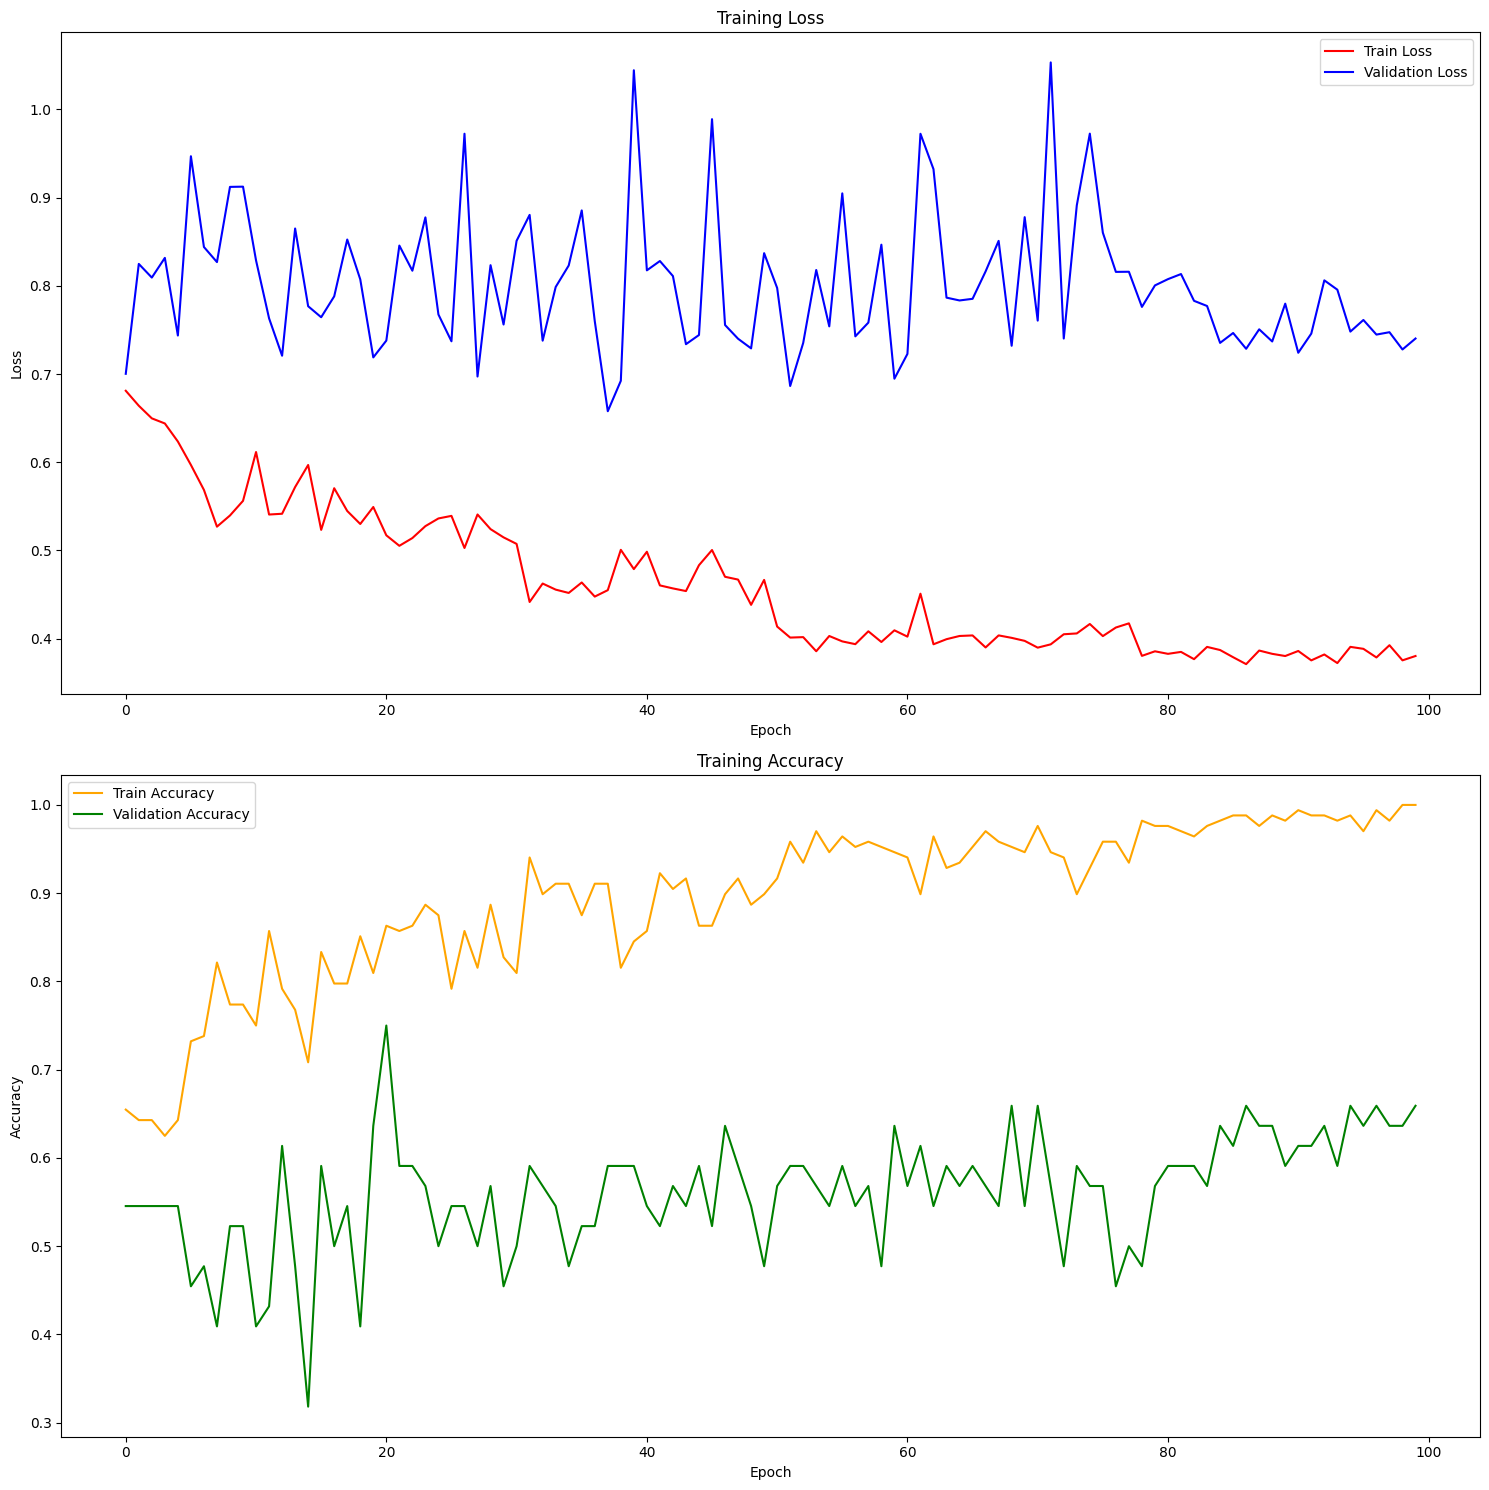

In [54]:
import matplotlib.pyplot as plt

# Load the results
result = open_pickle(SAVE_DIR, mode="all")

# train_loss = result['overall']['avg_train_loss']
# test_loss = result['overall']['avg_val_loss']
# train_acc = result['overall']['avg_train_accuracy']
# test_acc = result['overall']['avg_val_accuracy']

# # Fold {i} results
# fold = 1
# train_loss = result[f"fold_{fold}"]['train_loss']
# test_loss = result[f"fold_{fold}"]['val_loss']
# train_acc = result[f"fold_{fold}"]['train_accuracy']
# test_acc = result[f"fold_{fold}"]['val_accuracy']

# Holdout results
result = open_pickle(SAVE_DIR, mode="holdout")

train_loss = result['holdout']['train_loss']
test_loss = result['holdout']['val_loss']
train_acc = result['holdout']['train_accuracy']
test_acc = result['holdout']['val_accuracy']

# Assuming train_loss and train_accuracy are defined
x = range(len(train_loss))

fig, axs = plt.subplots(2, 1, figsize=(15, 15))

# Plot loss on the first axis
axs[0].plot(x, train_loss, 'r', label='Train Loss')
axs[0].plot(x, test_loss, 'b', label='Validation Loss')
axs[0].set_title('Training Loss')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()

# Plot accuracy on the second axis
axs[1].plot(x, train_acc, label='Train Accuracy', color='orange')
axs[1].plot(x, test_acc, label='Validation Accuracy', color='green')
axs[1].set_title('Training Accuracy')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.tight_layout()
plt.show()

#### Plotting: Confusion Matrix and ROC Curve

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, RocCurveDisplay, roc_auc_score

def plot_confusion_matrix(results, title="Confusion Matrix"):
    # Extract the confusion matrix from the results dictionary
    confusion_matrix = results['confusion_matrix']
    
    # Display the confusion matrix with specified class labels
    disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=["Healthy", "GAD"])
    disp.plot(cmap="Blues")
    plt.title(title)
    plt.show()

def plot_roc_curve(true_labels, pred_probs, title="ROC Curve"):
    """
    Plots the ROC Curve given true labels and predicted probabilities, with AUC displayed in the legend.
    Includes a diagonal reference line representing random chance (AUC = 0.5).
    
    Parameters:
    - true_labels (List[int]): The actual labels of the samples (0 or 1).
    - pred_probs (List[float]): The predicted probabilities for the positive class.
    - title (str): The title for the ROC plot.
    """
    # Calculate the false positive rate, true positive rate, and thresholds
    fpr, tpr, _ = roc_curve(true_labels, pred_probs, pos_label=1)
    
    # Calculate the AUC score
    auc_score = roc_auc_score(true_labels, pred_probs)
    
    # Plot the ROC curve with AUC in the legend
    plt.figure()
    RocCurveDisplay(fpr=fpr, tpr=tpr).plot()
    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
    
    # Plot the diagonal line for random classifier (AUC = 0.5)
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Classifier (AUC = 0.5)")
    
    plt.title(title)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")  # Add legend in the lower-right corner
    plt.show()


# Overall Results
result = open_pickle(SAVE_DIR, mode="all")
plot_confusion_matrix(result['overall'], title="Overall Confusion Matrix")
plot_roc_curve(result['overall']['true_labels'], result['overall']['pred_probs'], title="Overall ROC Curve")

# # Holdout Results
# result = open_pickle(SAVE_DIR, mode="holdout")
# plot_confusion_matrix(result['holdout'], title="Holdout Confusion Matrix")
# plot_roc_curve(result['holdout']['true_labels'], result['holdout']['pred_probs'], title="Holdout ROC Curve")